# GNN Training

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from gnn_project.config import Config
from gnn_project.training.train_utils import train_or_load_model, load_data

## GNN Model

In [2]:
config = Config(
    ml_data_dir='/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data',
    experiment_name='gnn_v1',
    sim_start=0,
    sim_end=2*60*60,
    load_saved_model=True,
    overwrite_data=False,
    log_level='DEBUG',
)

In [3]:
import logging
logging.basicConfig(level=config.log_level)

In [4]:
data, masks = load_data(config)

/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/dataloaders/gnn_dataloader.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_graphs = torch.load(t

## Feature Names
Access feature names for analysis

In [5]:
from gnn_project.training.train_utils import load_feature_names

# Load feature names for the current experiment
feature_names = load_feature_names(config)

# Display feature names for each node/edge type
for key, names in feature_names.items():
    print(f"\n{key}: {len(names)} features")
    print(names[:5] if len(names) > 5 else names)  # Show first 5 features

DEBUG:gnn_project.dataloaders.gnn_dataloader:Loaded feature names from /Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/processed/gnn_v1/feature_names.json



request: 42 features
['clustering_coeff', 'd_lat', 'd_lon', 'demand_supply_ratio', 'direct_td']

vehicle: 21 features
['clustering_coeff', 'in_degree', 'in_degree_from_requests', 'lat', 'lon']

vehicle__connects__request: 46 features
['arrival_slack', 'assigned_max_pooling_score', 'assigned_mean_pooling_score', 'assigned_min_max_detour_ratio', 'assigned_overlap_count']

request__connects__request: 71 features
['avg_detour_distance', 'avg_detour_ratio', 'avg_shared_ride_time', 'avg_time_detour', 'avg_time_detour_ratio']


In [6]:
model, trainer = train_or_load_model(config, data, masks)

INFO:gnn_project.training.train_utils:Loading model from /Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/models/gnn_v1/best_model.pt


## Visualization

In [7]:
logging.basicConfig(level='INFO')

In [8]:
from gnn_project.analysis.plots import visualize_graph
from gnn_project.training.train_utils import get_edge_predictions
from gnn_project.defaults import *

scenario = 0  # Scenario index for the selected graph
scenario_sizes = [240, 238, 240]  # Example scenario sizes
scenario_start_idx = sum(scenario_sizes[:scenario])


DEBUG:matplotlib:matplotlib data path: /Users/hoda_hamdy/Documents/Tools/Anaconda/envs/FleetPy/lib/python3.10/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/hoda_hamdy/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/hoda_hamdy/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/hoda_hamdy/.matplotlib/fontlist-v390.json


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/hoda_hamdy/Documents/Tools/Anaconda/envs/FleetPy/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/hoda_hamdy/Documents/Tools/Anaconda/envs/FleetPy/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/hod

Edge from r7 to r1: score=0.42, is_true=True, type=RR
Edge from r4 to r1: score=0.27, is_true=False, type=RR
Edge from r5 to r1: score=0.16, is_true=False, type=RR
Edge from r10 to r1: score=0.05, is_true=False, type=RR
Edge from r3 to r1: score=0.04, is_true=False, type=RR


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font7/f40f0181bac46ce79e53d040ad5075b8221f78e1.asset/AssetData/Charm.ttc', name='Charm', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font7/e5b038333b21d35a7cab9653e3551c464452f70b.asset/AssetData/Charmonman.ttc', name='Charmonman', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/NotoSansThaana-Regular.ttf', name='Noto Sans Thaana', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/STIXSizFourSymBol.otf', name='STIXSizeFourSym', style='normal', variant=

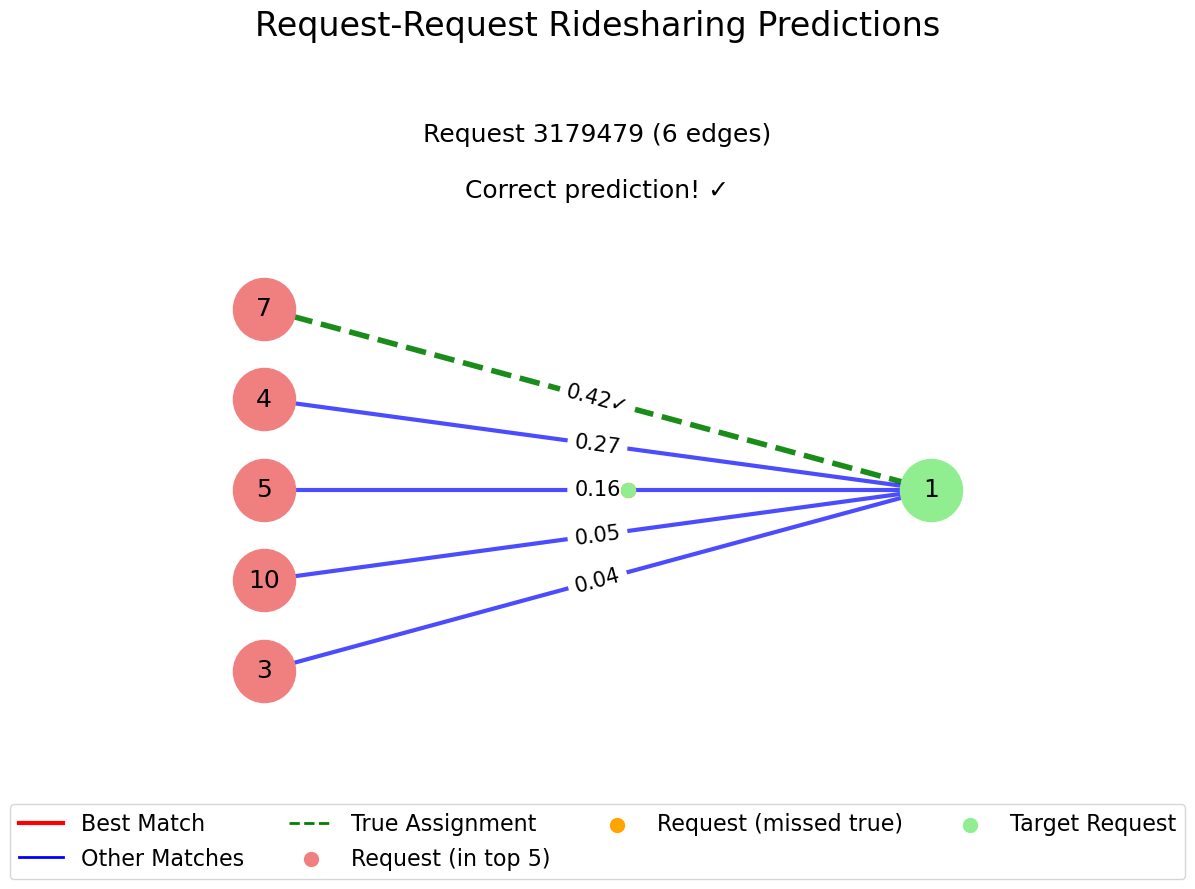

In [9]:
graph_idx = 12 # Index of the graph to visualize
predictions = get_edge_predictions(data[graph_idx], model, device='cpu')
edge_types = [RR_EDGE_NAME]
visualize_graph(data, graph_idx=graph_idx, predictions=predictions, edge_types=edge_types, scenario_start_idx=scenario_start_idx);

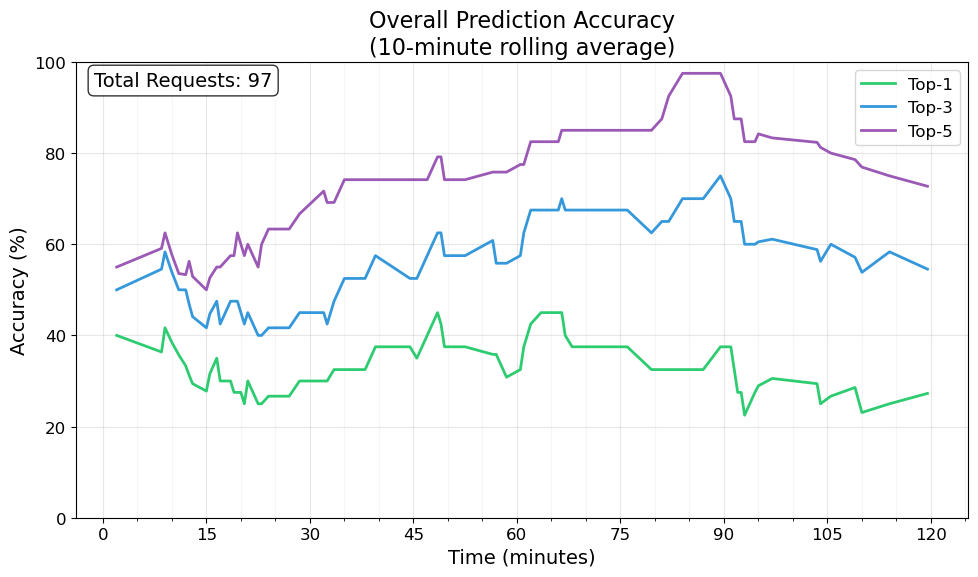

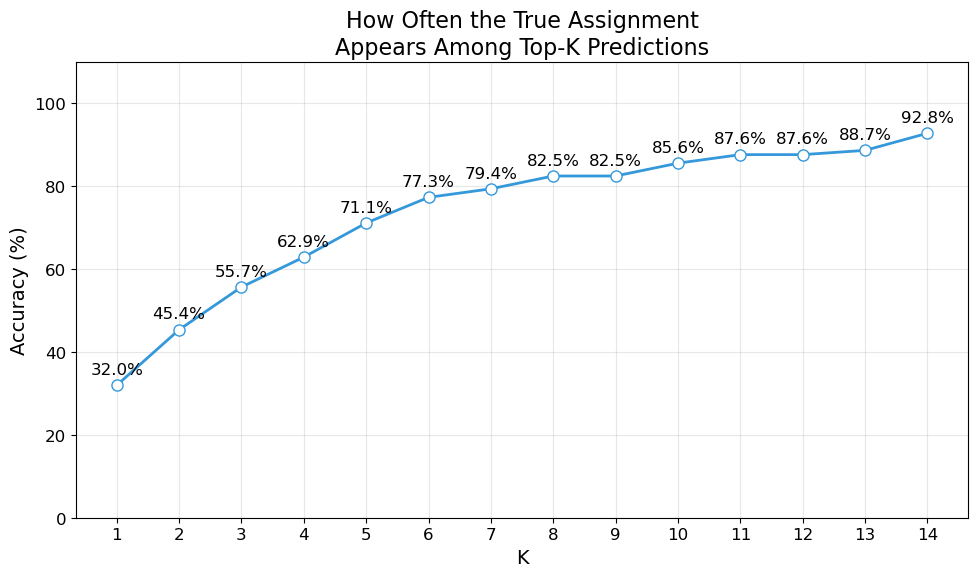

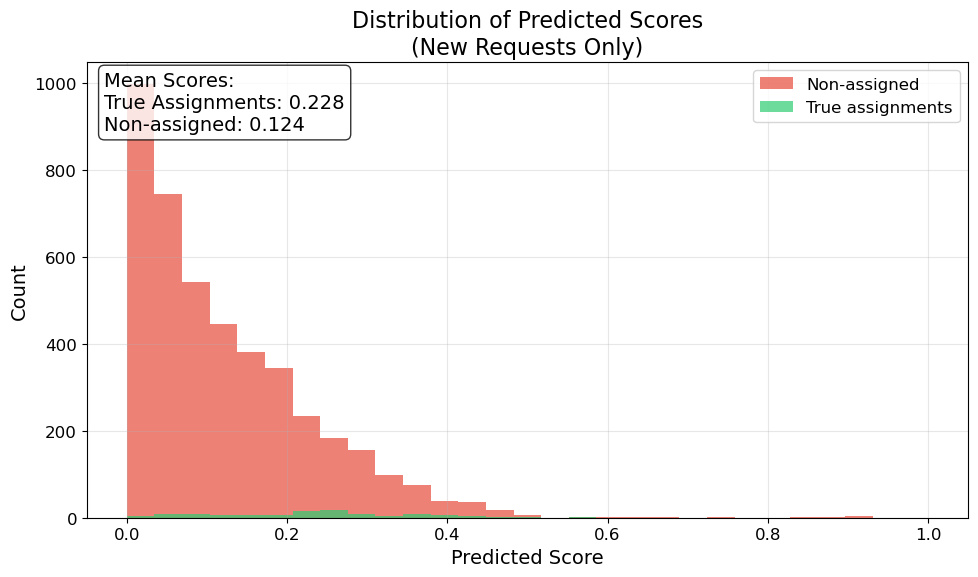

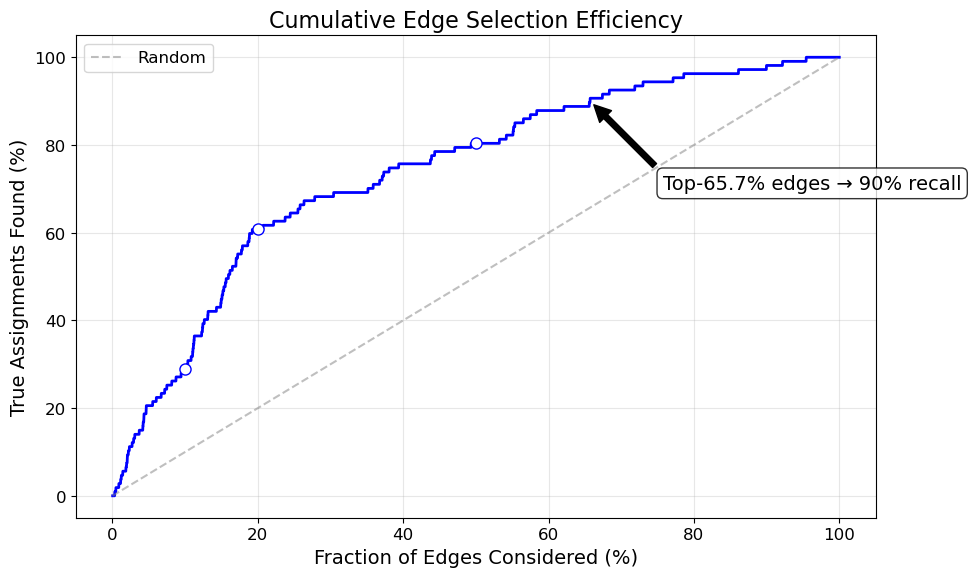

In [13]:
# Analyze model performance over a range of graphs
from gnn_project.analysis.plots import analyze_model_performance
import matplotlib.pyplot as plt
from gnn_project.defaults import *
num_graphs = masks[TEST_MASKS].sum().item()
start_idx = len(data) - num_graphs  # Starting graph index

edge_types = [RR_EDGE_NAME]
predictions = [get_edge_predictions(data[i], model, device=config.device) for i in range(start_idx, start_idx + num_graphs)]
fig = analyze_model_performance(data, start_idx, num_graphs, predictions, edge_types=edge_types)

In [11]:
for i, graph in enumerate(data):
    edge_type = RR_EDGE_NAME
    # find an true assignment edge and print the graph index to ease visualization
    if graph[edge_type].y.sum().item() > 0:
        print(f"Graph {i} has true assignments.")
        # print the edges with true assignments
        edge_indices = graph[edge_type].edge_index[:, graph[edge_type].y == 1]
        print(f"True assignment edges (source -> target):")
        for src, tgt in edge_indices.t().tolist():
            print(f"{src} -> {tgt}")
        break  # Stop after finding the first graph with true assignments

Graph 12 has true assignments.
True assignment edges (source -> target):
1 -> 7
7 -> 1
